# Unsupervised Machine Learning

**AS4501 — Astroinformatics**  
Francisco Förster Burón

---

## Plan

| # | Block | Time |
|---|---|---|
| 0 | [Setup & objectives](#block-0) | 5 min |
| 1 | [Why unsupervised?](#block-1) | 10 min |
| 2 | [Visualizing high-dim data](#block-2) | 20 min |
| 3 | [Linear dimensionality reduction (PCA, NMF)](#block-3) | 25 min |
| 4 | [Manifold learning (LLE, Isomap, t-SNE, UMAP)](#block-4) | 30 min |
| — | **Break** | 10 min |
| 5 | [Clustering foundations (k-means, GMM)](#block-5) | 30 min |
| 6 | [DBSCAN/HDBSCAN + hierarchical](#block-6) | 25 min |
| 7 | [Cluster validation](#block-7) | 10 min |
| 8 | [Semi-supervised teaser](#block-8) | 8 min |
| 9 | [Autoencoder bridge + wrap-up](#block-9) | 7 min |

<a id="block-0"></a>
# 0. Setup & objectives  *(5 min)*

**By the end of this two lectures you will be able to:**

- Choose a dimensionality-reduction method appropriate to the geometry of your data (linear vs manifold, global vs local).
- Run and interpret k-means, GMM, DBSCAN/HDBSCAN, and hierarchical clustering on photometric data.
- Evaluate a clustering using internal (silhouette) and external (ARI, NMI) metrics when partial labels exist.
- Recognize when semi-supervised learning is the right tool.

**Datasets used today**

| Dataset | Source | Used in |
|---|---|---|
| Iris | seaborn | quick sanity demo |
| SDSS stars + QSOs | `data/SDSS_stars.csv`, `data/SDSS_QSO.dat` | main astro thread |
| MNIST digits | `sklearn.datasets.load_digits` | manifold visualization |
| COMBO-17 | `data/COMBO17_lowz.dat` | hierarchical clustering |
| S-curve | `sklearn.datasets.make_s_curve` | toy for LLE/Isomap |

In [1]:
# Reproducibility & imports
RNG_SEED = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

sns.set(style='ticks')

np.random.seed(RNG_SEED)

/home/fforster/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Version check
import sklearn, scipy, matplotlib
print('numpy   ', np.__version__)
print('pandas  ', pd.__version__)
print('sklearn ', sklearn.__version__)
print('scipy   ', scipy.__version__)
print('mpl     ', matplotlib.__version__)

numpy    2.4.4
pandas   3.0.2
sklearn  1.6.1
scipy    1.15.3
mpl      3.10.0


In [3]:
# Build the SDSS stars+QSOs dataset used throughout the lecture
stars = pd.read_csv('data/SDSS_stars.csv')
QSOs  = pd.read_csv('data/SDSS_QSO.dat', sep=r'\s+', index_col='SDSS')

def add_colors(df, label):
    df = df.copy()
    df['cat'] = label
    df['u-g'] = df.u_mag - df.g_mag
    df['g-r'] = df.g_mag - df.r_mag
    df['r-i'] = df.r_mag - df.i_mag
    df['i-z'] = df.i_mag - df.z_mag
    return df[['u-g', 'g-r', 'r-i', 'i-z', 'cat']]

stars_c = add_colors(stars, 'star')
qsos_c  = add_colors(QSOs,  'QSO')

astrodata      = pd.concat([stars_c, qsos_c.sample(5000, random_state=RNG_SEED)])
astrodata_full = pd.concat([stars_c, qsos_c])
for d in (astrodata, astrodata_full):
    d['cat'] = d['cat'].astype('category')

astrodata.sample(5, random_state=RNG_SEED)

,u-g,g-r,r-i,i-z,cat
171020.47+305905.6,0.505000,-0.057000,0.097000,-0.012000,QSO
4684,1.661182,0.636036,0.142340,0.208149,star
1731,2.212597,0.858935,0.306581,0.151029,star
4742,1.239212,0.463112,0.148357,0.087942,star
4521,1.334276,0.535843,0.211907,0.058298,star


<a id="block-1"></a>
# 1. Why unsupervised?  *(10 min)*

- No labeled data. Goal: discover structure. Also called **knowledge discovery**.
- Most human/animal learning is unsupervised:

> *When we're learning to see, nobody's telling us what the right answers are — we just look. Every so often, your mother says "that's a dog", but that's very little information ... The brain's visual system has $10^{14}$ neural connections, and you only live for $10^9$ seconds. So it's no use learning one bit per second. You need more like $10^5$ bits per second. And there's only one place you can get that much information: from the input itself.*  — Geoffrey Hinton, 1996

## Why it matters in astronomy

- **Photometric classification**: $10^9$ photometric sources, $\le 10^7$ spectroscopic labels.
- **Anomaly detection** in time-domain surveys (ZTF, LSST).
- **Citizen-science discovery** of unexpected populations (Hanny's Voorwerp, green peas).
- **Compression and visualization** of high-dimensional spectra and light curves.

## Good visualization can save lives

![](../images/Borkin_2d.png)

Borkin et al. 2011 — *rainbow* colormaps obscure clinically important pressure features in coronary CT. Switching to a perceptually uniform colormap improved diagnostic accuracy in their user study.

![](images/arteries.png)

<a id="block-2"></a>
# 2. Visualizing high-dim data  *(20 min)*

## 2.1 Perceptually uniform colormaps

![](images/spectrum.jpg)

Requirements for a good colormap: **perceptually uniform**, **monochrome-printable**, **colorblind-friendly**, **representative of the data**.

![](../images/jet_test.png) ![](../images/gray_test.png) ![](../images/viridis_test.png)

Compare jet vs viridis on real-world video: `videos/jet.mp4`, `videos/viridis.mp4`.

**Jet**
<video controls src="videos/jet.mp4" />

**Viridis**
<video controls src="videos/viridis.mp4" />

## 2.2 Plots for many dimensions

The Iris dataset has 4 features: a perfect minimum example for 4D visualization.

![](../images/iris.png)

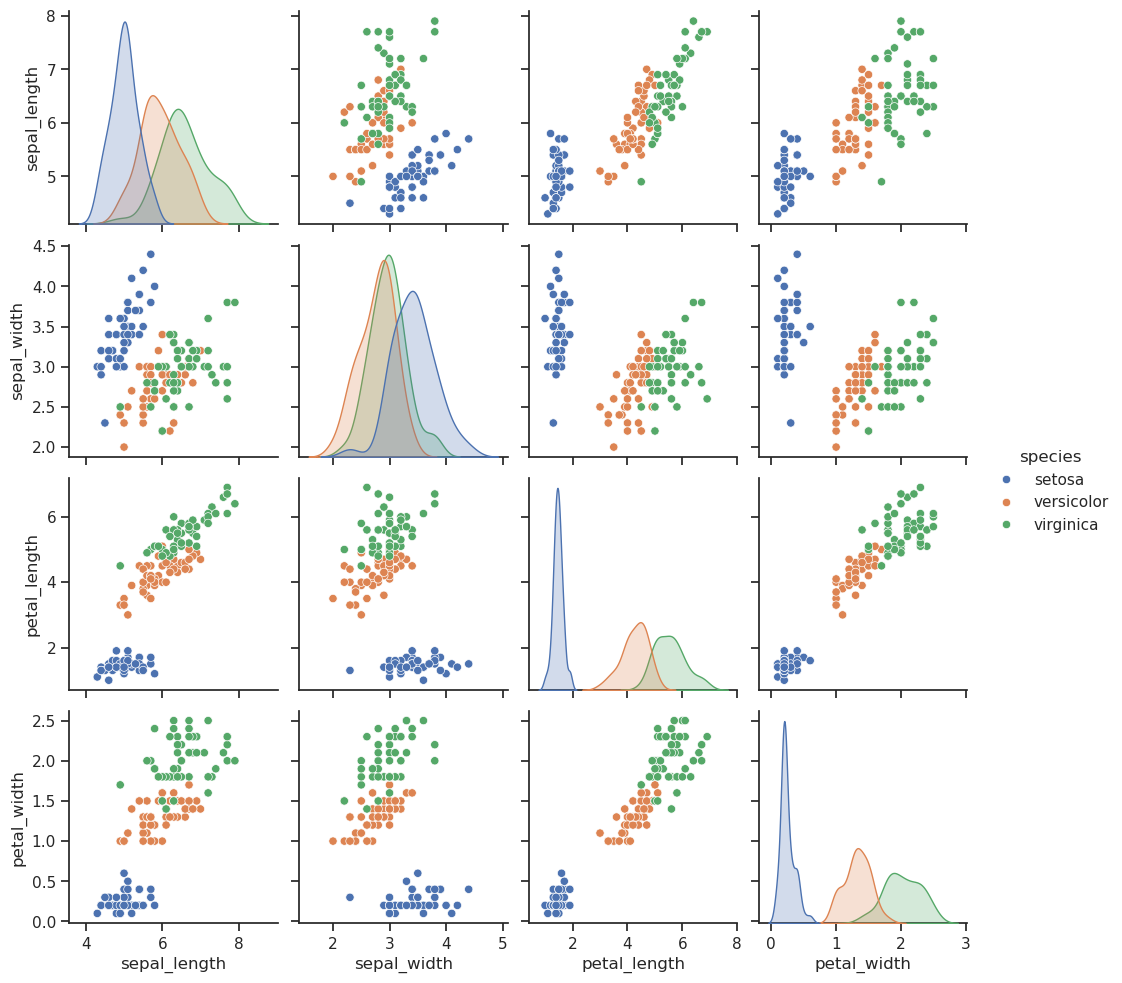

In [4]:
dfIris = sns.load_dataset('iris')
sns.pairplot(dfIris, hue='species');

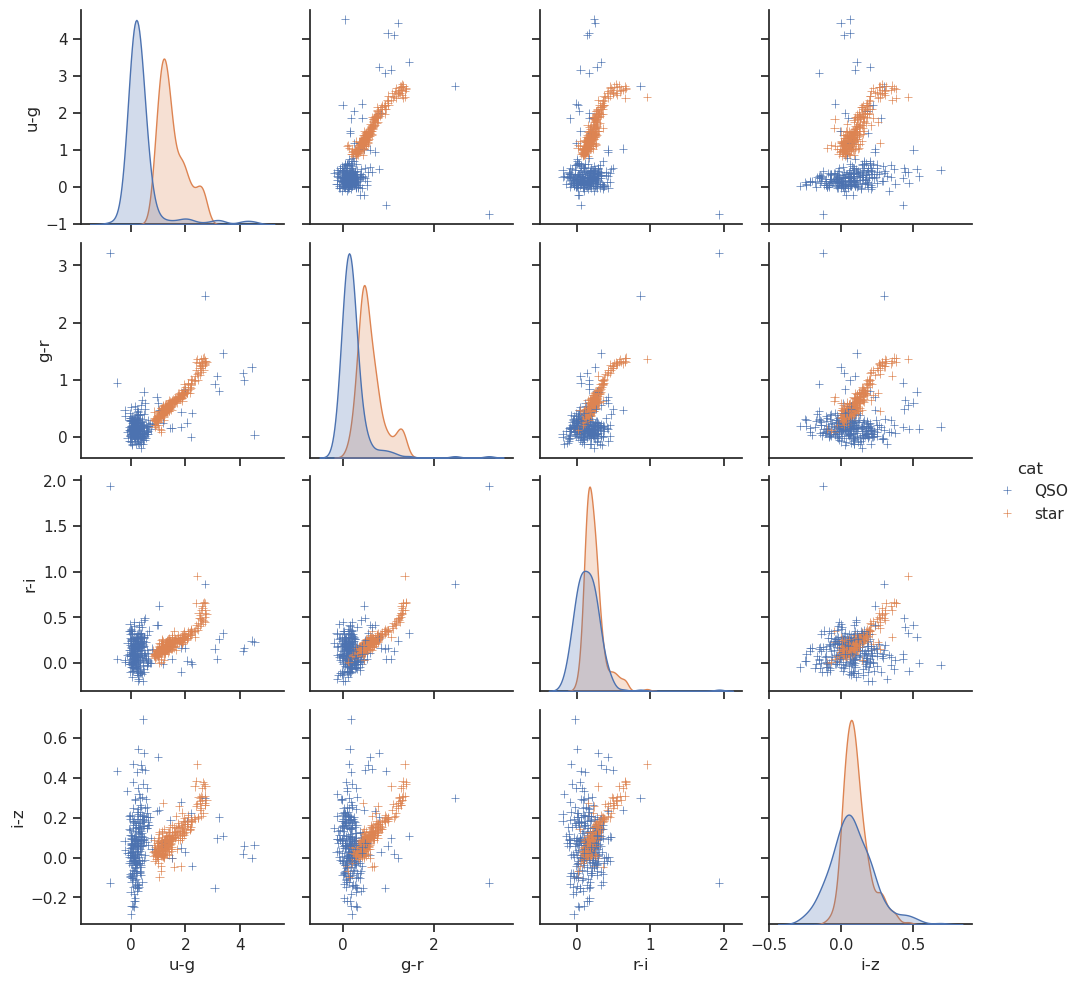

In [5]:
# Same idea on SDSS — pair plot of u-g, g-r, r-i, i-z
sns.pairplot(astrodata.sample(500, random_state=RNG_SEED), hue='cat', markers='+');

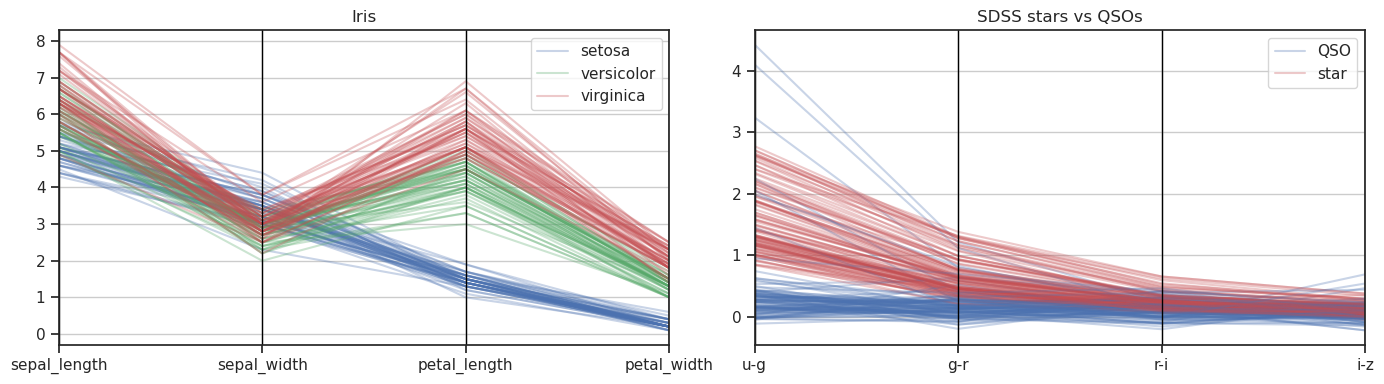

In [6]:
# Parallel coordinates
from pandas.plotting import parallel_coordinates
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
parallel_coordinates(dfIris, 'species', color=('b', 'g', 'r'), alpha=0.3, ax=axes[0])
axes[0].set_title('Iris')
parallel_coordinates(astrodata.sample(200, random_state=RNG_SEED), 'cat',
                     color=('b', 'r'), alpha=0.3, ax=axes[1])
axes[1].set_title('SDSS stars vs QSOs')
plt.tight_layout();

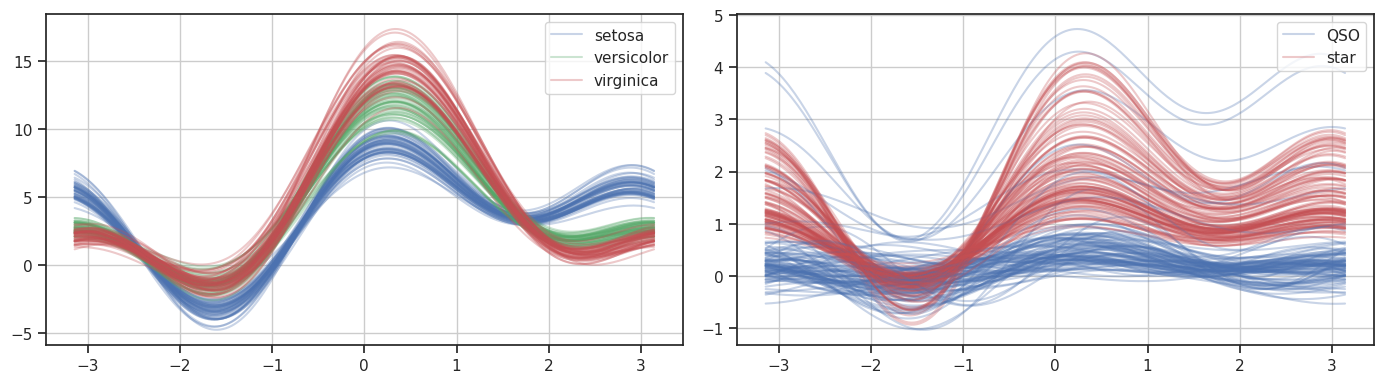

In [7]:
# Andrews curves: f(t) = x1/sqrt(2) + x2 sin t + x3 cos t + x4 sin 2t + ...
from pandas.plotting import andrews_curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
andrews_curves(dfIris, 'species', color=('b', 'g', 'r'), alpha=0.3, ax=axes[0])
andrews_curves(astrodata.sample(200, random_state=RNG_SEED), 'cat',
               color=('b', 'r'), alpha=0.3, ax=axes[1])
plt.tight_layout();

Radar plots 

![](images/radarplots.png)

https://towardsdatascience.com/plotting-in-many-dimensions-382fbd7fe76e

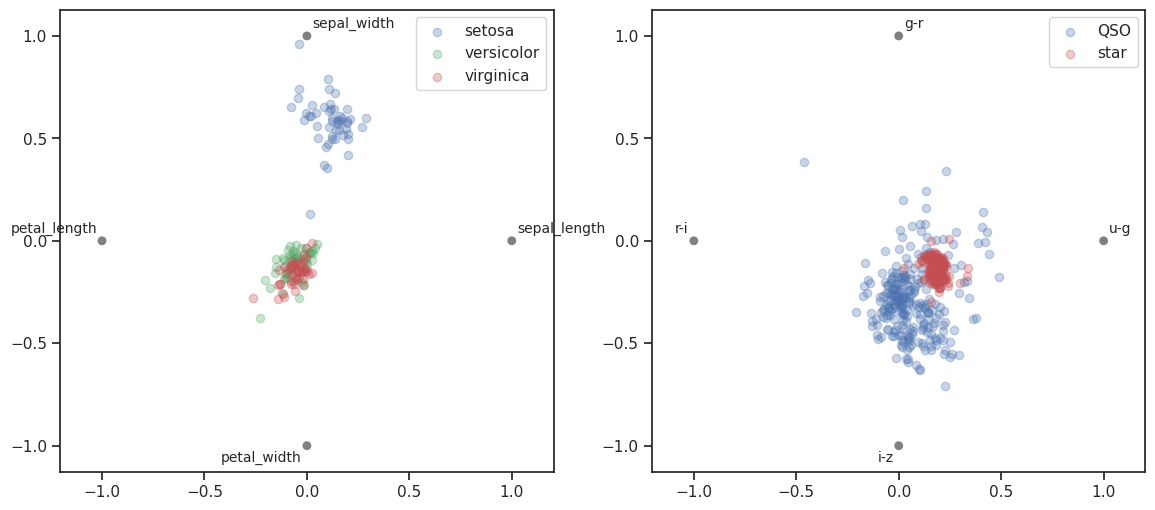

In [8]:
# RadViz
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pd.plotting.radviz(dfIris, 'species', ax=axes[0], color=('b', 'g', 'r'), alpha=0.3)
pd.plotting.radviz(astrodata.sample(500, random_state=RNG_SEED), 'cat',
                   ax=axes[1], color=('b', 'r'), alpha=0.3);

### Exercise 2.1

Pick **one** of {pair plot, parallel coordinates, Andrews curves, RadViz} and argue in one sentence which features best separate stars from QSOs in SDSS color space.

*Hint: which color index changes most strongly across the two classes?*

<a id="block-3"></a>
# 3. Linear dimensionality reduction  *(25 min)*

## 3.1 The curse of dimensionality

![](../images/dimensionality.png)

As $D$ grows, volume becomes sparse and statistics become hard. The fix is to **project to a lower-dimensional subspace** that captures the meaningful variability.

## 3.2 Scaling matters

Most DR methods use a distance — features on different scales dominate or vanish. Standard / robust / quantile scalers are the usual choices.

In [9]:
from sklearn.preprocessing import StandardScaler

astroX = np.array(astrodata.drop(columns=['cat']))
cats   = astrodata['cat']

astroX_full = np.array(astrodata_full.drop(columns=['cat']))
cats_full   = astrodata_full['cat']

scaler      = StandardScaler().fit(astroX)
scaler_full = StandardScaler().fit(astroX_full)

astroX      = scaler.transform(astroX)
astroX_full = scaler_full.transform(astroX_full) 

In [10]:
pd.DataFrame(data=astroX).describe()

,0,1,2,3
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,2.273737e-16,-9.094947e-17,6.821210e-17,1.136868e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-3.169648e+00,-2.297354e+00,-1.038854e+01,-5.960549e+00
25%,-8.836805e-01,-7.117777e-01,-5.235976e-01,-5.575489e-01
50%,-1.652199e-02,-1.347969e-01,-6.789007e-02,-1.202691e-01
75%,5.656908e-01,4.175814e-01,4.434534e-01,4.504182e-01
max,5.611108e+00,1.095217e+01,1.062148e+01,1.365775e+01


## 3.3 Principal Component Analysis (PCA)

- Orthogonal linear transformation that finds directions of **maximal variance**.
- Found by eigendecomposition of the covariance matrix or by SVD of the centered data matrix.
- New basis $\{v_i\}$ ordered by decreasing eigenvalue. The $i$-th coordinate of a point $x$ is the projection $\langle x, v_i \rangle$.

![](../images/PCAAnimation.gif)

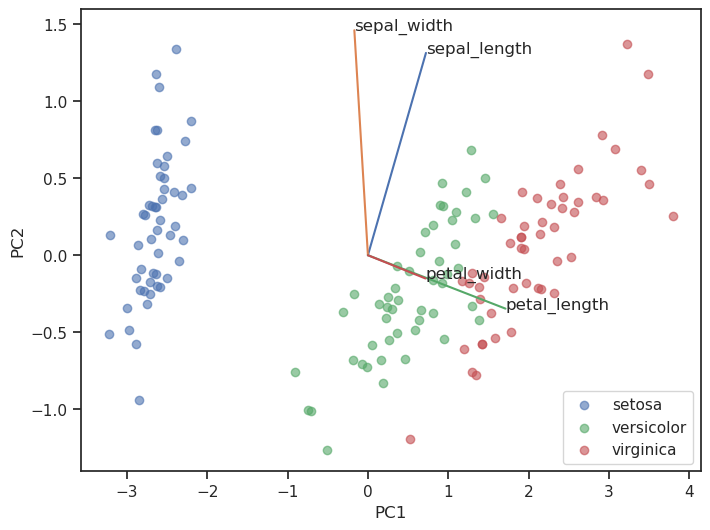

In [11]:
from sklearn import decomposition

# Iris
iris_X       = np.array(dfIris.drop(columns=['species']))
species      = dfIris['species']
iris_colors  = {'setosa': 'b', 'versicolor': 'g', 'virginica': 'r'}
astro_colors = {'star': 'r', 'QSO': 'b'}

pca_iris = decomposition.PCA(n_components=2, random_state=RNG_SEED).fit(iris_X)
iris_pca = pca_iris.transform(iris_X)

fig, ax = plt.subplots(figsize=(8, 6))
for sp in np.unique(species):
    m = (species == sp)
    ax.scatter(iris_pca[m, 0], iris_pca[m, 1], c=iris_colors[sp], label=sp, alpha=0.6)
ev = 2 * pca_iris.components_
for k, v in enumerate(dfIris.columns[:-1]):
    ax.plot([0, ev[0, k]], [0, ev[1, k]])
    ax.text(ev[0, k], ev[1, k], v)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend();

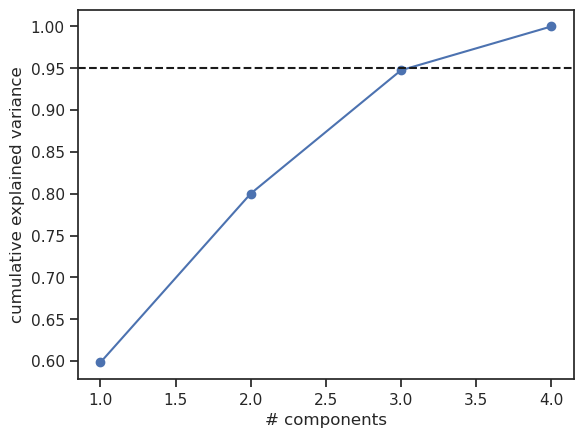

In [12]:
# Explained variance — how many components capture 95%?
pca_full = decomposition.PCA(random_state=RNG_SEED).fit(astroX)
cum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(np.arange(1, len(cum) + 1), cum, 'o-')
plt.axhline(0.95, ls='--', c='k')
plt.xlabel('# components'); plt.ylabel('cumulative explained variance');

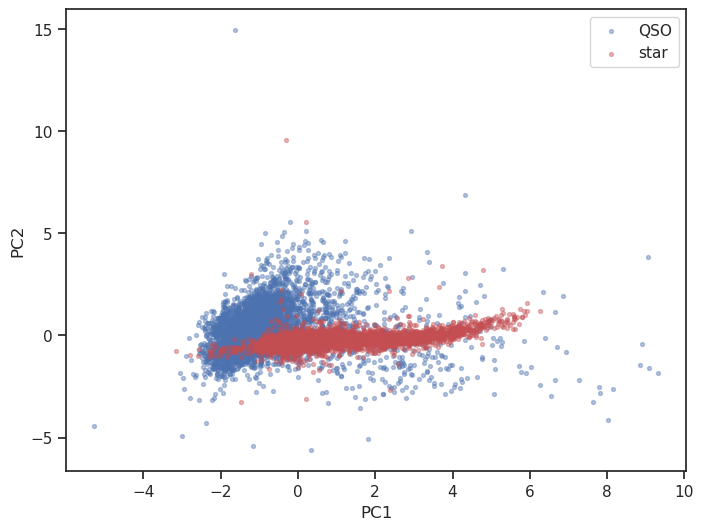

In [13]:
# SDSS stars vs QSOs in PC space
pca_astro = decomposition.PCA(n_components=2, random_state=RNG_SEED).fit(astroX)
astro_pca = pca_astro.transform(astroX)

fig, ax = plt.subplots(figsize=(8, 6))
for c in cats.cat.categories:
    m = (cats == c)
    ax.scatter(astro_pca[m, 0], astro_pca[m, 1], c=astro_colors[c], label=c, alpha=0.4, s=8)
ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2');

## 3.4 Non-negative Matrix Factorization (NMF)

Decompose a positive-valued data matrix as the product of two positive-valued matrices.

![](../images/NMF.png)

Components are additive parts (no cancellation). For images, NMF tends to find localized features (eyes, mouths) where PCA finds global eigenmodes.

**$V \in \mathbb{R}^{MxN}$**. Positive data matrix. It contains N samples and M dimensions (data points are columns).

**$W \in \mathbb{R}^{MxK}$**. Positive dictionaries matrix. Columns are the basis vectors or **prototypes**.

**$H \in \mathbb{R}^{KxN}$**. Positive coefficients matrix.

sometimes this is written as $V^T = H^T W^T$. It depends on how you present the data to the method.


This is achieved by minimizing the error function

$\Large \min\limits_{W,H}^{} || V - W H ||^2_F + \lambda ||H||_1,~~~~ s.t.~~~ W \ge 0, H \ge 0$

Note that $v_i = W h_i$, where $v_i$ is the i-th column vector of **V** and $h_i$ is the i-th column vector of **H**

## 3.5 MNIST: PCA vs NMF

![](../images/eigenfaces-big.png)

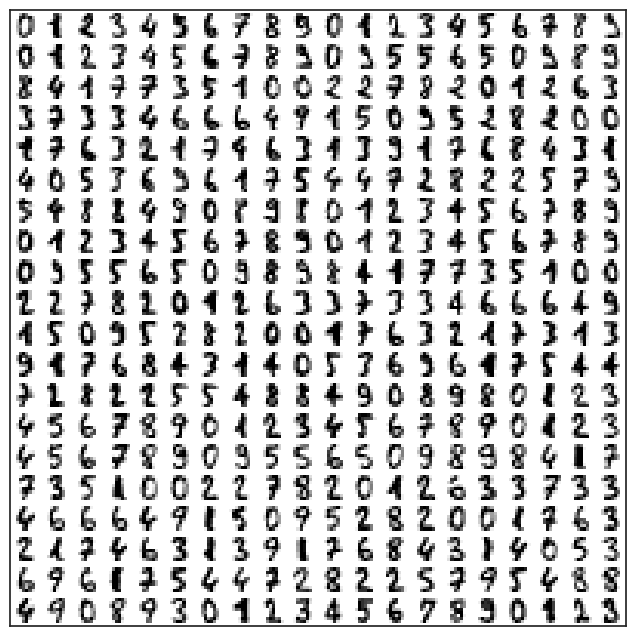

In [14]:
from sklearn import datasets

digits = datasets.load_digits()
X, y = digits.data, digits.target

# Show 20x20 grid of digits
nrows = 20
img = np.zeros((10 * nrows, 10 * nrows))
for i in range(nrows):
    for j in range(nrows):
        img[10*i+1:10*i+9, 10*j+1:10*j+9] = X[i*nrows + j].reshape(8, 8)
plt.figure(figsize=(8, 8)); plt.imshow(img, plt.cm.binary); plt.xticks([]); plt.yticks([]);

In [15]:
# Helper: scaled scatter with digit labels
from matplotlib import offsetbox

def plot_embedding(X, title=None, target=None):
    target = digits.target if target is None else target
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)
    fig, ax = plt.subplots(figsize=(8, 8))
    for i in range(X.shape[0]):
        ax.text(X[i, 0], X[i, 1], str(target[i]),
                color=plt.cm.Set1(target[i] / 10.),
                fontdict={'weight': 'bold', 'size': 9})
    shown = np.array([[1., 1.]])
    for i in range(X.shape[0]):
        if np.min(np.sum((X[i] - shown) ** 2, 1)) < 4e-3:
            continue
        shown = np.r_[shown, [X[i]]]
        ab = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r), X[i])
        ax.add_artist(ab)
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)

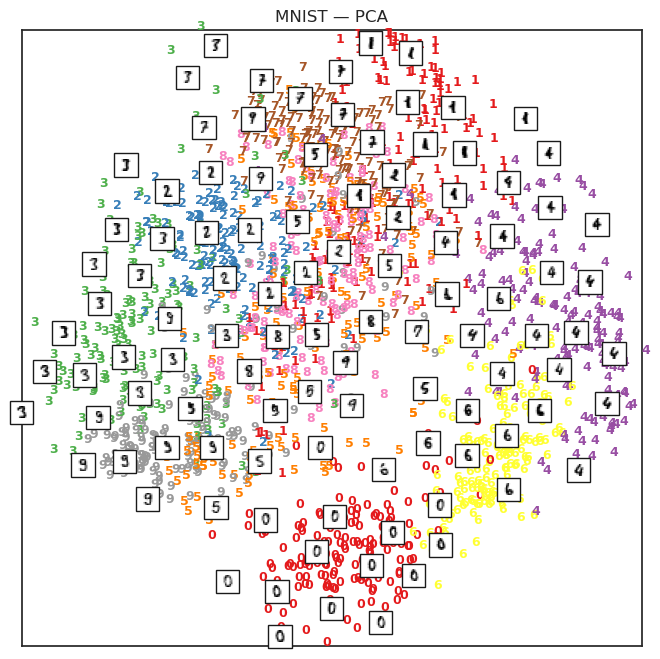

In [16]:
pca_mnist = decomposition.PCA(n_components=2, random_state=RNG_SEED).fit_transform(X)
plot_embedding(pca_mnist, 'MNIST — PCA')

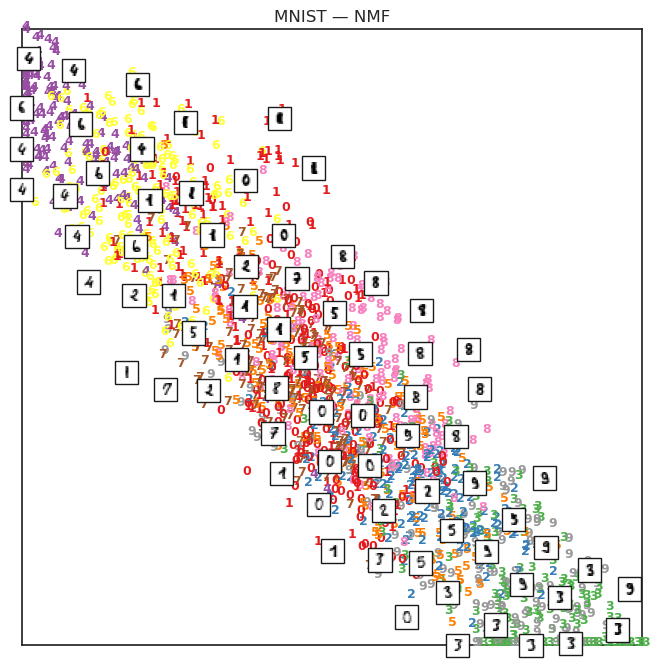

In [17]:
nmf_mnist = decomposition.NMF(n_components=2, init='nndsvd', random_state=RNG_SEED,
                              max_iter=400).fit_transform(X)
plot_embedding(nmf_mnist, 'MNIST — NMF')

### Exercise 3.1
How many PCA components are needed to capture 95% of the variance in the SDSS color space? *(Use the cumulative explained-variance plot above.)*

<a id="block-4"></a>
# 4. Manifold learning  *(30 min)*

PCA finds a *linear* subspace. If the data lies on a curved manifold, linear methods waste components. Manifold methods preserve local structure.

## LLE and Isomap on the S-curve

Local Linear Embedding

* Non-linear dimensionality reduction method.

* It tries to find a lower-dimensional embedding which preserves **local** distances between points

*Algorithm:*

    1. Find K nearest neighbors per data point
    2. Build local linear model around reference point, minimizing reconstruction error:

$\Large \epsilon(W) = \sum_i \large| \vec{X_i} - \sum_j W_{ij} \vec{X_j} \large|^2$

s.t. $\sum_j W_{ij} = 1$

    3. Reconstruct neighborhood in low dimensional space, with new errors 
    
$\Large \phi(Y) = \sum_i | \vec{Y_i} - \sum_j W_{ij} \vec{Y_j}|^2$

where now we solve for the values of $\vec{Y_i}$
    
    

## Isometric Mapping (Isomap)

    * Non-linear dimensionality reduction method.

    * It tries to find a lower-dimensional embedding which preserves distances between all points

*Algorithm*

1. Construct a neighborhood graph, where each point is connected to other if it is a K nearest neighbor, and the edge is the Euclidean distance
2. Compute all pairs of shortest paths on the above neighborhood graph
3. apply **multidimensional scaling** using the matrix of shortest-path distances

**Mutidimensional scaling**:

1. Assign points to arbitrary coordinates in p-dimensional space.
2. Compute euclidean distances among all pairs of points, to form a $\hat D$ matrix.
3. Compare the $\hat D$ matrix with the input $D$ matrix by evaluating the **stress** function. The smaller the value, the greater the correspondance between the two.
4. Adjust coordinates of each point in the direction that reduces stress.
5. Repeat steps 2 through 4 until stress won't get any lower. 

**Stress function**

And example of stress function is the following:

$\Large {Stress}_D(x_1, x_2, ..., x_N) = \biggl(\frac{\sum\limits_{i \ne j = 1,..N} (d_{ij} - ||x_i - x_j||^2)}{\sum_{ij} d^2_{ij}}\biggr)^{1/2}$

https://en.wikipedia.org/wiki/Multidimensional_scaling



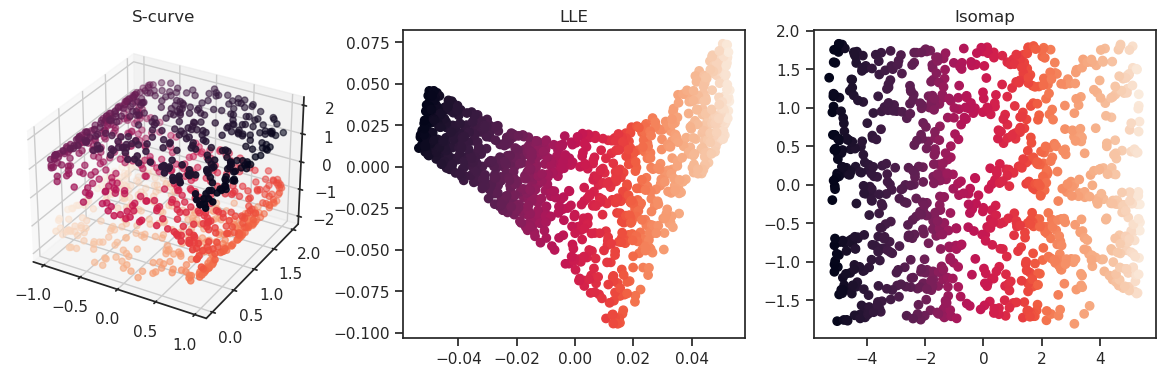

In [18]:
from sklearn.manifold import LocallyLinearEmbedding as LLE, Isomap

S, color = datasets.make_s_curve(1000, random_state=RNG_SEED)
S_s = StandardScaler().fit_transform(S)

fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot(131, projection='3d'); ax.scatter(S[:, 0], S[:, 1], S[:, 2], c=color); ax.set_title('S-curve')
Y_lle = LLE(n_components=2, n_neighbors=10, random_state=RNG_SEED).fit_transform(S_s)
ax = fig.add_subplot(132); ax.scatter(Y_lle[:, 0], Y_lle[:, 1], c=color); ax.set_title('LLE')
Y_iso = Isomap(n_components=2, n_neighbors=10).fit_transform(S_s)
ax = fig.add_subplot(133); ax.scatter(Y_iso[:, 0], Y_iso[:, 1], c=color); ax.set_title('Isomap');

## 4.2 t-SNE  *(van der Maaten & Hinton 2008)*


![](../images/tSNE_animation.gif)

##### SNE (Hinton & Roweis, 2002):

* Convert high-dimensional dataset $X={x_1, ..., x_n}$ into two or three dimensional dataset $Y={y_1, ..., y_n}$ to be displayed as a scatter plot.

* Start by converting high-dimensional Euclidean distances between datapoints into conditional probabilities $p_{j|i}$. 

* $p_{j|i}$ is the probability of picking $x_j$ as its neighbor if picked from a Gaussian centered at $x_i$.

$\Large p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2 \sigma_i^2)}{\sum_{k \ne i} \exp(-||x_i - x_k||^2 / 2 \sigma_i^2)}$

* Do the same for the low-dimensional counterparts (assume $\sigma_i = 1/\sqrt{2}$ for convenience):

$\Large q_{j|i} = \frac{\exp(-||y_i - y_j||^2)}{\sum_{k \ne i} \exp(-||y_i - y_k||^2)}$

* If the map points $y_i$ and $y_j$ correctly model the similarity between the high-dimensional datapoints $x_i$ and $x_j$, **the conditional probabilities $p_{j|i}$ and $q_{j|i}$ will be equal**.

* Use the Kullback-Leibler (KL) divergence between $P$ and $Q$ as the cost function!

**Kullback-Leibler distance**:

$\Large D_{KL}(P||Q) = \sum_i P(i) \ln \frac{P(i)}{Q(i)}$

* The cost function would then be:

$\Large C = \sum_i KL(P_i || Q_i) = \sum_i \sum_j p_{j|i} \ln \frac{p_{j|i}}{q_{j|i}}$

![](images/KL.png)

The previous assumptions make the cost function very simple:


$\Large C = \sum_i KL(P_i || Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$

* Need to choose $\sigma_i$. Small values better for dense regions, large values better for sparse regions.

* The distribution $P_i$ has an increasing entropy as $\sigma_i$ increases. 
* The user defines $\sigma_i$ via setting **the perplexity** (which defines the entropy and indirectly $P_i$):

$\Large Perp(P_i) = 2^{H(P_i)} = 2^{-\sum\limits_j p_{j|i} \log_2 p_{j|i}}$

* this method has the problem that it tends to cluster points at the center of the map

## t-SNE (van der Maaten & Hinton, 2008)

1. instead of using the (asymmetric) conditional probabilities $p_{j|i}$ use the following symmetrized version (symmetric to exchange between $i$ and $j$)

$\Large p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

2. use Student t-distribution with one degree of freedom in the low-dimensional map (a heavy-tailed distribution). This pushes data points away from the centre in the mapped space.

$\Large q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \ne l} (1 + ||y_k - y_l||^2)^{-1}}$

SNE and t-SNE have one **free parameter: the perplexity**, which is how well a probability distribution should predict the samples assuming the previous model.

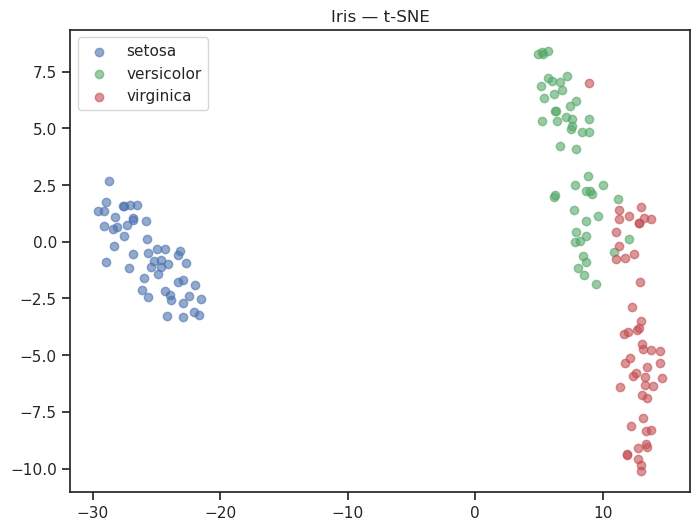

In [19]:
from sklearn.manifold import TSNE

tsne_iris = TSNE(n_components=2, init='pca', perplexity=25, random_state=RNG_SEED).fit_transform(iris_X)
tsne_mnist = TSNE(n_components=2, init='pca', perplexity=25, random_state=RNG_SEED).fit_transform(X)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for sp in np.unique(species):
    m = (species == sp)
    ax.scatter(tsne_iris[m, 0], tsne_iris[m, 1], c=iris_colors[sp], label=sp, alpha=0.6)
ax.set_title('Iris — t-SNE'); ax.legend();

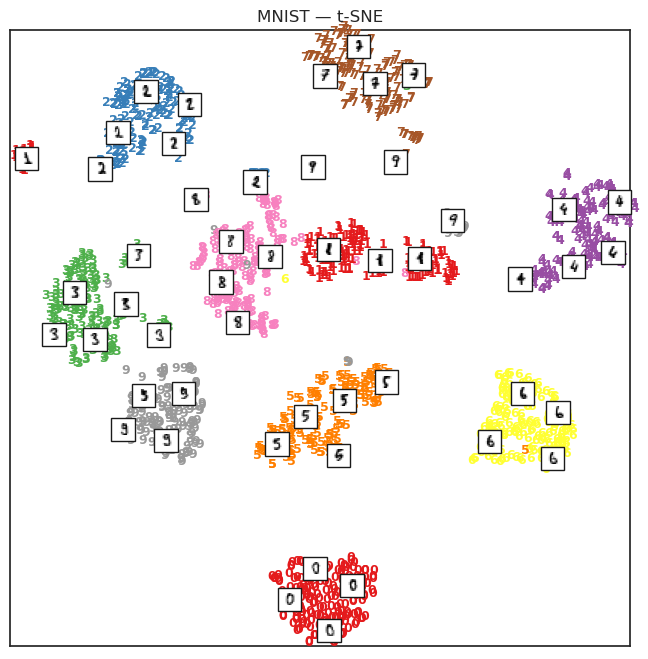

In [20]:
plot_embedding(tsne_mnist, 'MNIST — t-SNE')

## 4.3 UMAP

Like t-SNE but: faster, scales better, **preserves more global structure**, and supports `transform` on new data.

In [21]:
from IPython.display import HTML
HTML('<iframe width="900" height="500" src="https://www.youtube.com/embed/nq6iPZVUxZU" frameborder="0" allowfullscreen></iframe>')

/home/fforster/anaconda3/lib/python3.13/site-packages/IPython/core/display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


2026-04-29 15:58:46.435416: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 15:58:46.477972: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 15:58:47.953944: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/fforster/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWa

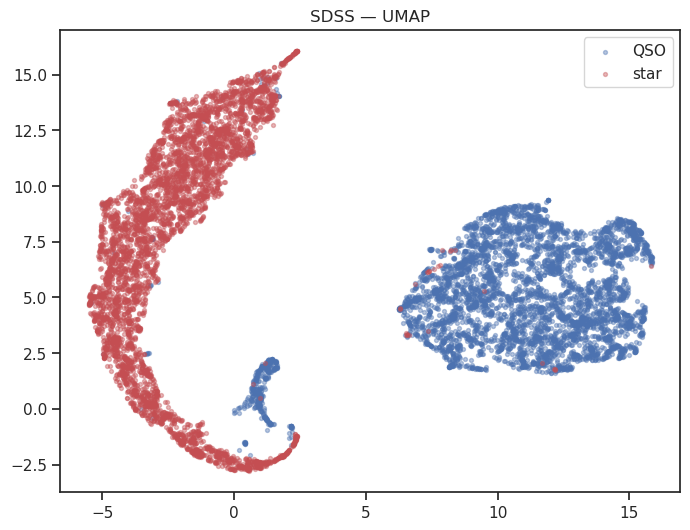

In [22]:
# pip install umap-learn
import umap

reducer = umap.UMAP(random_state=RNG_SEED)
astro_umap = reducer.fit_transform(astroX)

fig, ax = plt.subplots(figsize=(8, 6))
for c in cats.cat.categories:
    m = (cats == c)
    ax.scatter(astro_umap[m, 0], astro_umap[m, 1], c=astro_colors[c], label=c, alpha=0.4, s=8)
ax.legend(); ax.set_title('SDSS — UMAP');

/home/fforster/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


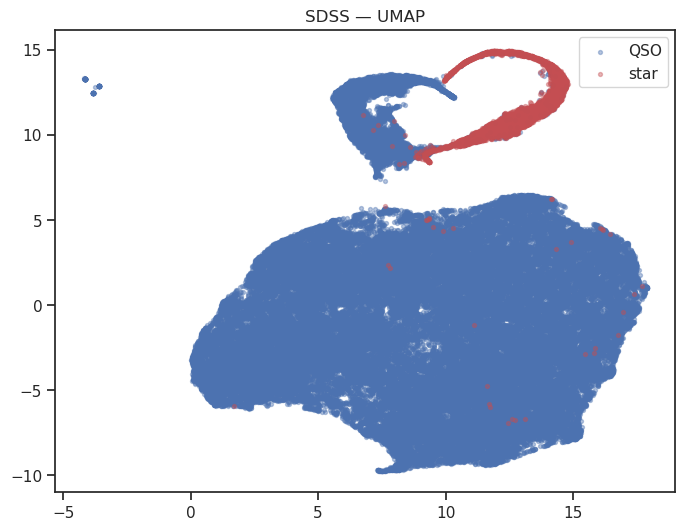

In [24]:
# pip install umap-learn
import umap

reducer = umap.UMAP(random_state=RNG_SEED)
astro_umap_full = reducer.fit_transform(astroX_full)

fig, ax = plt.subplots(figsize=(8, 6))
for c in cats_full.cat.categories:
    m = (cats_full == c)
    ax.scatter(astro_umap_full[m, 0], astro_umap_full[m, 1], c=astro_colors[c], label=c, alpha=0.4, s=8)
ax.legend(); ax.set_title('SDSS — UMAP');

/home/fforster/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


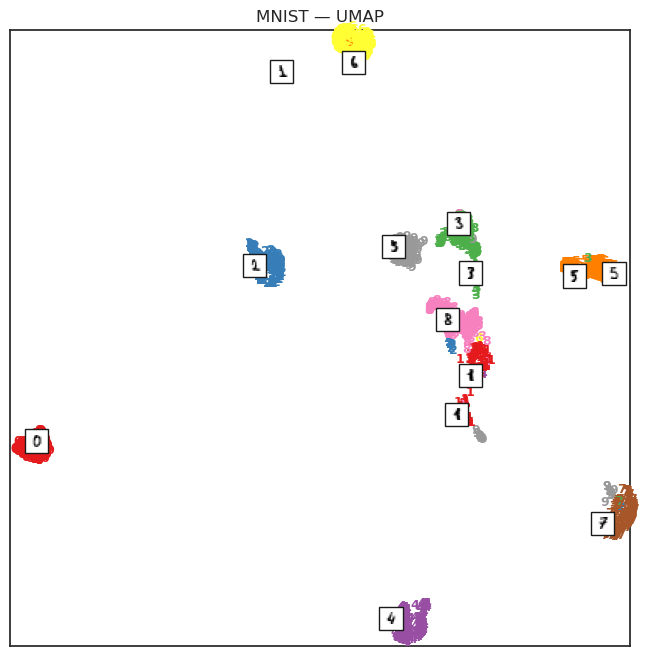

In [25]:
mnist_umap = umap.UMAP(random_state=RNG_SEED).fit_transform(X)
plot_embedding(mnist_umap, 'MNIST — UMAP')

### Exercise 4.1
Re-run UMAP on `astroX` with `n_neighbors` = 5 and 200. How does the global vs local trade-off shift? *(Hint: small n_neighbors → fragmented clusters; large → loses fine structure.)*

## 4.4 Decision guide

| Data shape | Use |
|---|---|
| Linear, dense | PCA |
| Strictly non-negative, additive parts | NMF |
| Curved manifold, want global structure | Isomap |
| Curved manifold, local structure | LLE, t-SNE |
| Want a `transform()` method for new data | PCA, UMAP |
| Big data ($10^6$+ points) | UMAP, PCA |

---
## ☕ Break
---

<a id="block-5"></a>
# 5. Clustering foundations  *(30 min)*

Clustering = grouping similar objects.

**Two kinds of input:**
1. *Similarity-based*: $N \times N$ dissimilarity matrix.
2. *Feature-based*: $N \times D$ design matrix.

**Two kinds of output:**
1. *Flat (partitional)* clustering — disjoint groups.
2. *Hierarchical* clustering — nested tree.

![](../images/clustering_comparison.png)



## 5.1 Dissimilarity

Most common: 

$\Delta(x_i, x_{i'}) = \sum_j \Delta_j(x_{ij}, x_{i'j})$ 

with 

$\Delta_j = (x_{ij} - x_{i'j})^2$ (squared Euclidean), 

$|x_{ij} - x_{i'j}|$ ($\ell_1$), correlation, etc.

## 5.2 k-means

Partition $n$ observations into $k$ clusters by minimizing within-cluster sum of squares:
$$\arg\min_S \sum_{i=1}^k \sum_{x \in S_i} \| x - \mu_i \|^2$$

Lloyd's algorithm: assign → update centroids → repeat. Cluster boundaries form a **Voronoi tessellation**.

![](../images/K-means_convergence.gif)

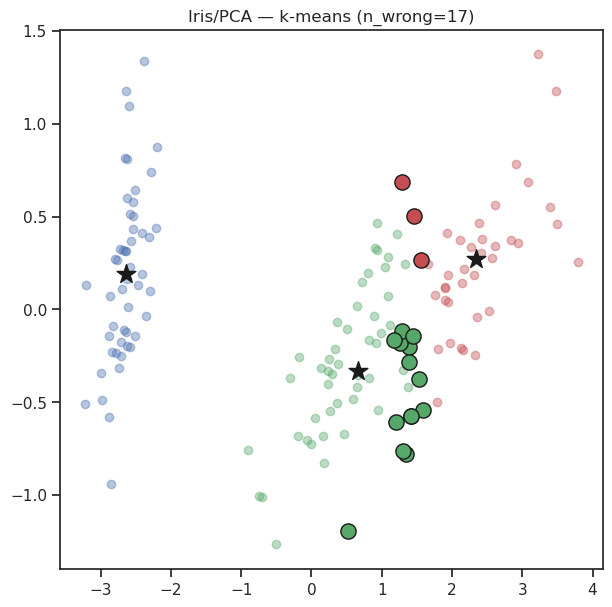

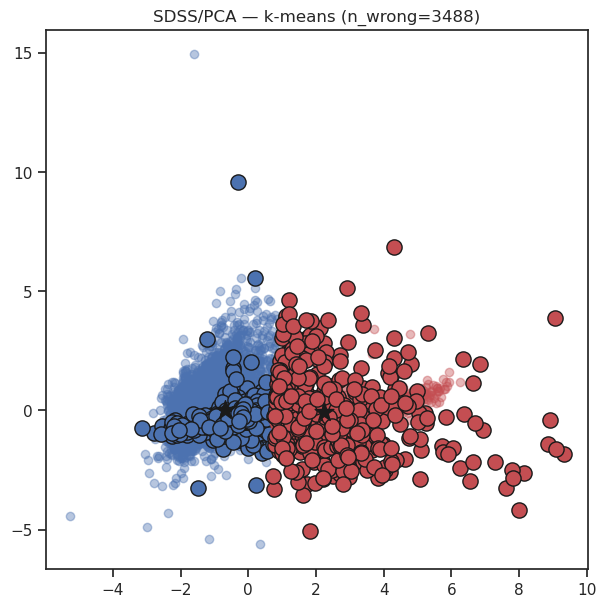

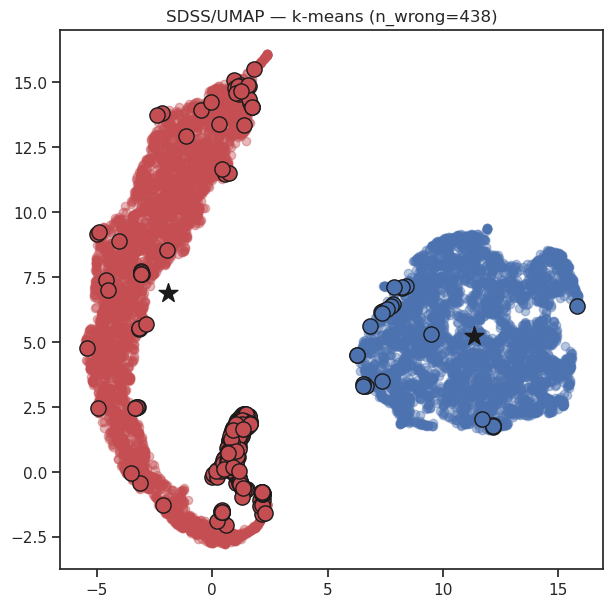

In [26]:
from sklearn.cluster import KMeans

def majority_label(values):
    """Most-frequent value, dtype-agnostic (works for strings/categories)."""
    uniq, counts = np.unique(values, return_counts=True)
    return uniq[counts.argmax()]

def dokmeans(X, n_clusters, label, true_labels, colors, ax=None):
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=RNG_SEED).fit(X)
    pred = km.labels_
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))
    n_wrong = 0
    true_arr = np.asarray(true_labels)
    for k in np.unique(pred):
        mask = (pred == k)
        majority = majority_label(true_arr[mask])
        wrong = mask & (true_arr != majority)
        n_wrong += wrong.sum()
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[majority], alpha=0.4)
        ax.scatter(X[wrong, 0], X[wrong, 1], c=colors[majority], s=120,
                   facecolor='none', edgecolor='k')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               marker='*', s=200, c='k')
    ax.set_title(f'{label} — k-means (n_wrong={n_wrong})')
    return km

_ = dokmeans(iris_pca,  3, 'Iris/PCA',  species, iris_colors)
_ = dokmeans(astro_pca, 2, 'SDSS/PCA',  cats,    astro_colors)
_ = dokmeans(astro_umap, 2, 'SDSS/UMAP', cats,    astro_colors)

## 5.3 Gaussian Mixture Models

$$p(x) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

Cluster shapes are ellipsoidal — **k-means is the limiting case** of GMM with isotropic equal-variance Gaussians.

### Choosing K via BIC

$$\mathrm{BIC} = -2 \ln \hat L + p \ln n$$

Lower is better. Sweep $K$, pick the elbow.

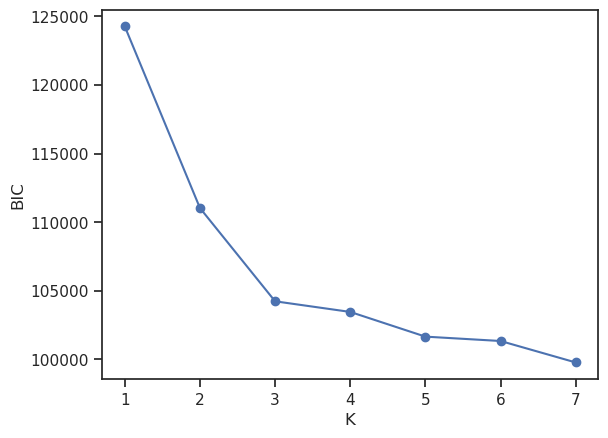

In [27]:
from sklearn.mixture import GaussianMixture

X_cluster = astro_umap
ks = range(1, 8)
bics = [GaussianMixture(n_components=k, random_state=RNG_SEED).fit(X_cluster).bic(X_cluster)
        for k in ks]
plt.plot(ks, bics, 'o-'); plt.xlabel('K'); plt.ylabel('BIC');

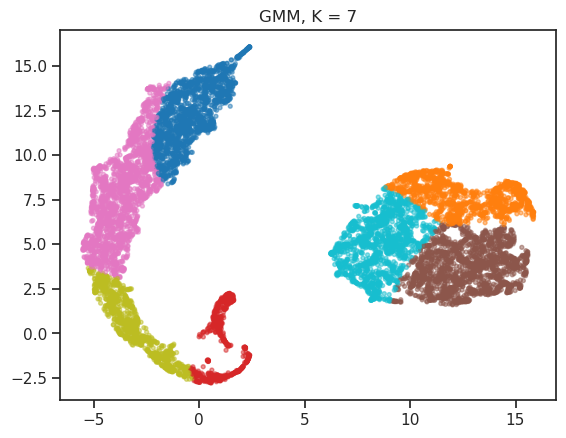

In [28]:
# GMM with the BIC-selected K
K_best = ks[int(np.argmin(bics))]
gmm = GaussianMixture(n_components=K_best, random_state=RNG_SEED).fit(X_cluster)
pred = gmm.predict(X_cluster)
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=pred, cmap='tab10', s=8, alpha=0.5)
plt.title(f'GMM, K = {K_best}');

<a id="block-6"></a>
# 6. Density-based and hierarchical  *(25 min)*

## 6.1 DBSCAN

![](../images/DBSCAN.png)

- Group points that are **densely packed**; mark sparse points as outliers.
- Two parameters: $\varepsilon$ (radius), `min_pts` (core threshold).
- Does **not** require choosing $K$.
- Struggles when clusters have very different densities → use **HDBSCAN**.

Algorithm:
1. a point $p$ is a core if at least $minpts$ points are within distance $\epsilon$. 
2. a point $q$ is directly reachable from $p$ if point $q$ is within distance $\epsilon$ from point $p$.
3. a point $q$ is reachable from $p$ if there is a path $p_1, ... p_n$ with $p_1 = p$ and $p_n = q$ where each $p_{i+1}$ is directly reachable from $p_i$ (all points on the path must be core point, with the possible exception of $q$).
4. all points not reachable from any other point are outliers

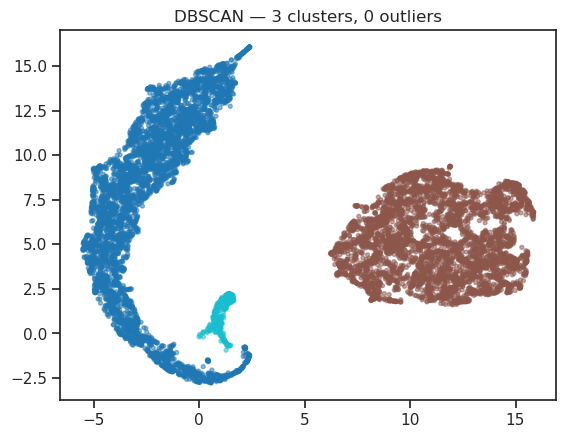

In [29]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10).fit(astro_umap)
plt.scatter(astro_umap[:, 0], astro_umap[:, 1], c=db.labels_, cmap='tab10', s=8, alpha=0.5)
plt.title(f'DBSCAN — {len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)} clusters, '
          f'{(db.labels_ == -1).sum()} outliers');

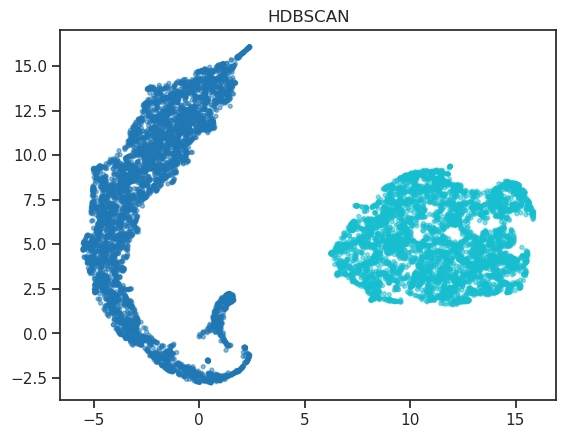

In [30]:
# HDBSCAN (sklearn >= 1.3)
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=30).fit(astro_umap)
plt.scatter(astro_umap[:, 0], astro_umap[:, 1], c=hdb.labels_, cmap='tab10', s=8, alpha=0.5)
plt.title('HDBSCAN');

## 6.2 Hierarchical clustering

![](../images/hierarchical.png)

Agglomerative: start with $n$ singleton clusters, merge the closest pair, repeat.

**Linkages** (cluster-to-cluster distance):
- *Single*: nearest member. Tends to chain.
- *Complete*: farthest member. Tends to over-compact.
- *Average*: mean over pairs.
- *Ward*: minimize total within-cluster variance. Often the safest default.

### Compute linkage matrix

A (n-1) by 4 matrix Z

At the i-th iteration, clusters with indices Z[i, 0] and Z[i, 1] are combined to form cluster.

A cluster with an index less than n+i corresponds to one of the original observations.

The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].

The fourth value Z[i, 3] represents the number of original observations in the newly formed cluster.

See https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

,0,1,2,3
0,0.0,8.0,0.028284,2.0
1,11.0,18.0,0.155242,2.0
2,21.0,22.0,0.200998,2.0
3,17.0,20.0,0.223607,2.0
4,4.0,26.0,0.282843,2.0
5,12.0,19.0,0.300000,2.0
6,10.0,23.0,0.332415,2.0
7,3.0,34.0,0.396989,3.0
8,1.0,14.0,0.400000,2.0
9,2.0,35.0,0.443847,3.0


,0,1,2,3
0,0.0,8.0,0.028284,2.0
1,11.0,18.0,0.155242,2.0
2,21.0,22.0,0.200998,2.0
3,17.0,20.0,0.223607,2.0
4,4.0,26.0,0.282843,2.0
5,12.0,19.0,0.300000,2.0
6,10.0,23.0,0.332415,2.0
7,1.0,14.0,0.400000,2.0
8,2.0,3.0,0.588303,2.0
9,13.0,28.0,0.600167,2.0


,0,1,2,3
0,0.0,8.0,0.028284,2.0
1,11.0,18.0,0.155242,2.0
2,21.0,22.0,0.200998,2.0
3,17.0,20.0,0.223607,2.0
4,4.0,26.0,0.282843,2.0
5,12.0,19.0,0.300000,2.0
6,10.0,23.0,0.332415,2.0
7,1.0,14.0,0.400000,2.0
8,3.0,34.0,0.508656,3.0
9,2.0,35.0,0.533773,3.0


,0,1,2,3
0,0.0,8.0,0.028284,2.0
1,11.0,18.0,0.155242,2.0
2,21.0,22.0,0.200998,2.0
3,17.0,20.0,0.223607,2.0
4,4.0,26.0,0.282843,2.0
5,12.0,19.0,0.300000,2.0
6,10.0,23.0,0.332415,2.0
7,1.0,14.0,0.400000,2.0
8,3.0,34.0,0.578734,3.0
9,13.0,28.0,0.600167,2.0


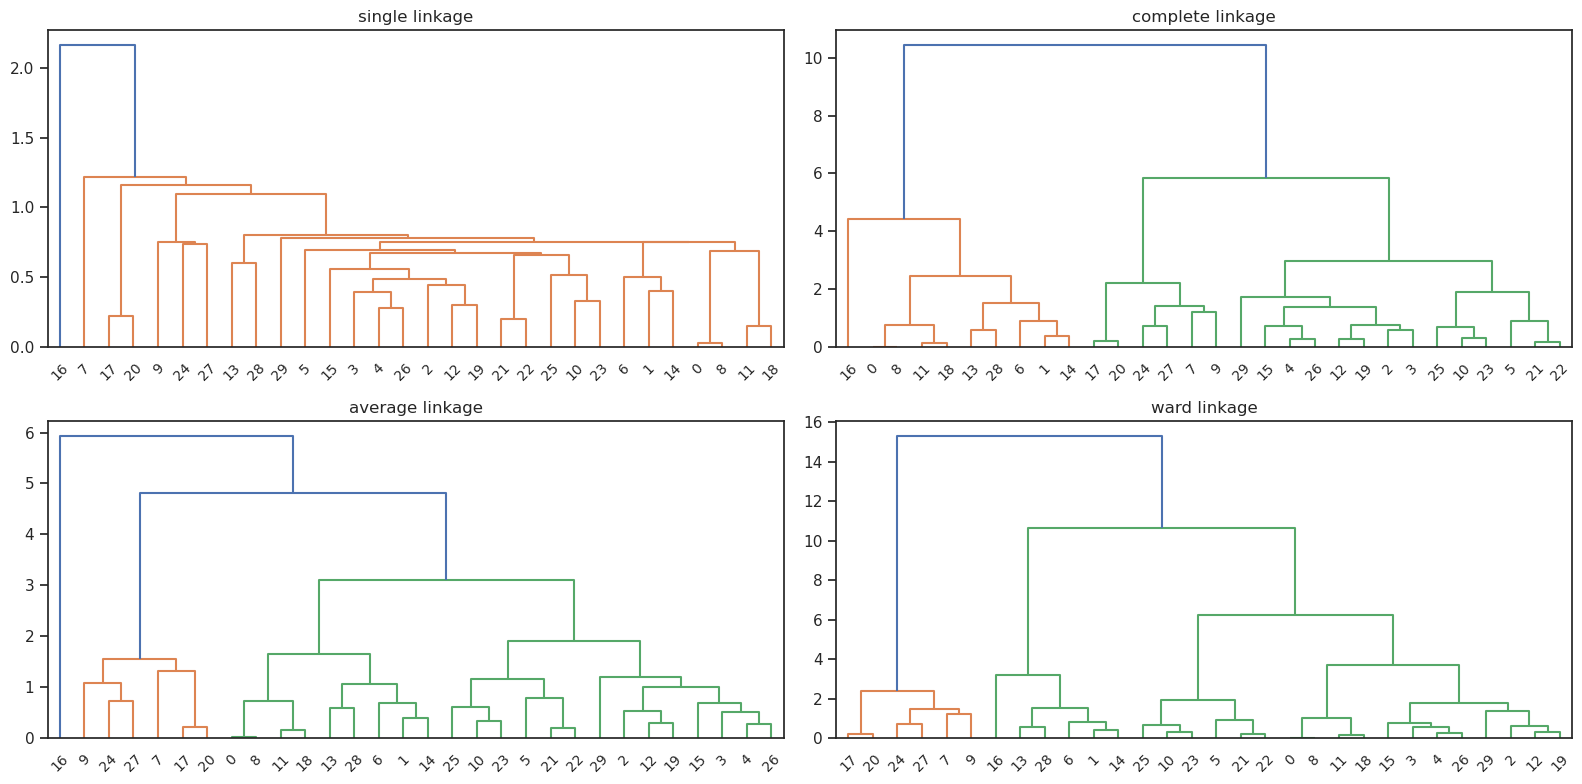

In [31]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv('data/COMBO17_lowz.dat', sep=r'\s+').sample(30, random_state=RNG_SEED)
dist = pdist(df.values)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, method in zip(axes.flat, ['single', 'complete', 'average', 'ward']):
    Z = linkage(dist, method)
    dendrogram(Z, ax=ax)
    ax.set_title(f'{method} linkage')
    display(pd.DataFrame(Z))
plt.tight_layout();

### Exercise 6.1
Why does single linkage produce *chain-like* dendrograms while Ward produces *balanced* ones? *(Hint: think about merging two large clusters that share one outlier.)*

<a id="block-7"></a>
# 7. Cluster validation  *(10 min)*

![](../images/unsupervisedmetrics.png)

## Internal metrics (no labels)
- **Silhouette score** ∈ [−1, 1]. Higher = better separated, tighter clusters.
- **Davies–Bouldin** — lower is better.

## External metrics (require ground truth)
- **Adjusted Rand Index (ARI)** ∈ [−1, 1]. 1 = perfect, 0 = chance.
- **Normalized Mutual Information (NMI)** ∈ [0, 1].

In [32]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, normalized_mutual_info_score)

km = KMeans(n_clusters=2, n_init=10, random_state=RNG_SEED).fit(astro_umap)
pred = km.labels_
truth = cats.cat.codes.values

print(f'Silhouette       : {silhouette_score(astro_umap, pred):.3f}')
print(f'Davies-Bouldin   : {davies_bouldin_score(astro_umap, pred):.3f}')
print(f'ARI vs cat       : {adjusted_rand_score(truth, pred):.3f}')
print(f'NMI vs cat       : {normalized_mutual_info_score(truth, pred):.3f}')

Silhouette       : 0.613
Davies-Bouldin   : 0.611
ARI vs cat       : 0.832
NMI vs cat       : 0.769


<a id="block-8"></a>
# 8. Semi-supervised teaser  *(8 min)*

Realistic astro setting: 100 spectroscopic labels, $10^6$ photometric points. Throwing away the unlabeled data is a waste.

## Label propagation

Do label propagation of the unlabeled data first (see Zhu & Ghahramani, 2002,  http://pages.cs.wisc.edu/~jerryzhu/pub/CMU-CALD-02-107.pdf)

Let $(x_1, y_1)...(x_l, y_l)$ be labeled data, where $Y_L = \lbrace y_1, ..y_l \rbrace$ are the class labels.

We assume the number of classes $C$ is known, and all classes are present in the labeled data. 

Let $(x_{l+1}, y_{l+1}, ... (x_{l + u}, y_{l + u})$ be unlabeled data where $Y_U = \lbrace y_{l + 1}, ... y_{l +u} \rbrace$ are unobserved, usually $l << u$



The problem is estimating $Y_U$ from $X$ and $Y_L$, which is a **transductive learning** setting.

Also define a $(l+u) \times C$ label matrix $Y$, whose $ith$ row represents the label probability distribution of node $x_i$.

Define $T_{ij}$ the probabilistic transition matrix:

$\Large T_{ij} = P(j \rightarrow i) = \frac{w_{ij}}{\sum\limits_{k=1}^{l+u} w_{kj}}$

where

$\Large w_{ij} = \exp\biggl(-\frac{d_{ij}^2}{\sigma^2}\biggr)$, which is controled by parameter $\sigma$

*Algorithm*

1. Propagate $Y \leftarrow T Y$

2. Row normalize $Y$

3. Clamp the labeled data. Repeat from step 1 until $Y$ converges
![](../data/labelpropagation.png)

*Optional (skip if running long): Variational Bayesian GMM (`BayesianGaussianMixture`) — Dirichlet prior automatically prunes unused components.*

In [33]:
from sklearn.semi_supervised import LabelPropagation

# Hide 90% of the SDSS labels and recover them
y_full = cats.cat.codes.values.copy()
rng = np.random.RandomState(RNG_SEED)
hidden = rng.rand(len(y_full)) < 0.9
y_partial = y_full.copy()
y_partial[hidden] = -1

lp = LabelPropagation(kernel='knn', n_neighbors=10).fit(astro_umap, y_partial)
acc = (lp.transduction_[hidden] == y_full[hidden]).mean()
print(f'Recovered {acc:.1%} of hidden labels')

Recovered 99.1% of hidden labels


<a id="block-9"></a>
# 9. Bridge & wrap-up  *(7 min)*

## 9.1 Autoencoder teaser

![](../data/autoencoder.png)

An autoencoder is a neural network that learns to compress (encoder) and reconstruct (decoder) its input. The bottleneck is a learned, *non-linear* embedding — the natural extension of PCA into deep learning. **We cover this in detail in the `ML_NNs` notebook.**

## 9.2 Method picker

| You want to... | Try |
|---|---|
| Visualize 4–10 features | pair plot, parallel coordinates |
| Reduce dimension, linear | PCA |
| Reduce dimension, manifold | UMAP (default), t-SNE |
| Reduce dimension, parts-based, non-negative data | NMF |
| Cluster, K known, convex blobs | k-means |
| Cluster, K unknown via BIC, ellipsoidal | GMM |
| Cluster, varying density, want outliers | HDBSCAN |
| Cluster, want a tree | hierarchical (Ward) |
| Validate clustering, no labels | silhouette |
| Validate clustering, partial labels | ARI, NMI |
| Few labels, many unlabeled | label propagation, autoencoder + classifier |

## 9.3 Homework

Take the **full** SDSS dataset (`astrodata_full`), reduce it with UMAP, cluster with HDBSCAN, and report ARI vs the `cat` ground truth. Comment on whether any HDBSCAN noise points are systematically QSOs or stars.